In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
california = fetch_california_housing(as_frame=True)
df = california.frame

In [3]:
# ---------------------------------------------------------
# Step 1: Data Loading & Exploration
# ---------------------------------------------------------

# Our Target is 'MedHouseVal' (Median House Value in $100,000s)
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

In [4]:
# ---------------------------------------------------------
# Step 2: Train/Test Split
# We keep 20% of the data hidden to test for overfitting later!
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [5]:
# ---------------------------------------------------------
# Step 3: Feature Scaling (CRITICAL FOR REGULARIZATION)
# Regularization penalizes large weights. If 'Income' is in the 10,000s 
# and 'Rooms' is in the 1s, their weights will be on totally different scales.
# StandardScaler forces all features to have a mean of 0 and variance of 1.
# ---------------------------------------------------------
Scaler = StandardScaler()
X_train_scaled = Scaler.fit_transform(X_train)
X_test_scaled = Scaler.transform(X_test)

In [6]:
# ---------------------------------------------------------
# Step 4: Model Training & Hyperparameter Tuning
# We use RidgeCV and LassoCV to automatically test different Lambda values!
# ---------------------------------------------------------

# Model A: Standard Linear Regression (No Penalty)
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)
# Model B: Ridge (L2) - Testing alphas (lambdas) from 0.1 to 100
ridge_reg = RidgeCV(alphas=np.logspace(-1,2,10))
ridge_reg.fit(X_train_scaled, y_train)
# Model C: Lasso (L1) - Testing alphas from 0.001 to 10
lasso_reg = LassoCV(alphas=np.logspace(-3,1,10))
lasso_reg.fit(X_train_scaled,y_train)

,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"n_alphas n_alphas: int, default=100Number of alphas along the regularization path... deprecated:: 1.7 `n_alphas` was deprecated in 1.7 and will be removed in 1.9. Use `alphas` instead.",'deprecated'
,"alphas alphas: array-like or int, default=NoneValues of alphas to test along the regularization path.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`... deprecated:: 1.7 `alphas=None` was deprecated in 1.7 and will be removed in 1.9, at which point the default value will be set to 100.",array([1.0000...00000000e+01])
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: 'auto', bool or array-like of shape (n_features, n_features), default='auto'Whether to use a precomputed Gram matrix to speed upcalculations. If set to ``'auto'`` let us decide. The Grammatrix can also be passed as argument.",'auto'
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``.",0.0001
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"cv cv: int, cross-validation generator or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- int, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For int/None inputs, :class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: bool or int, default=FalseAmount of verbosity.",False
,"n_jobs n_jobs: int, default=NoneNumber of CPUs to use during the cross validation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [7]:
# ---------------------------------------------------------
# Step 5: Evaluation
# ---------------------------------------------------------
def evaluate_model(name,model,X_test,y_test):
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test,y_pred))
    mae = mean_absolute_error(y_test,y_pred)
    r2 = r2_score(y_test,y_pred)
    print(f"--- {name} ---")
    print(f"RMSE: {rmse:.3f} (Average error in $100k units)")
    print(f"MAE:  {mae:.3f} (Absolute average error)")
    print(f"R²:   {r2:.3f} (Percentage of variance explained)")
    print()

evaluate_model("Standard Linear", lin_reg, X_test_scaled, y_test)
evaluate_model(f"Ridge (Best Alpha: {ridge_reg.alpha_:.2f})", ridge_reg, X_test_scaled, y_test)
evaluate_model(f"Lasso (Best Alpha: {lasso_reg.alpha_:.4f})", lasso_reg, X_test_scaled, y_test)

--- Standard Linear ---
RMSE: 0.746 (Average error in $100k units)
MAE:  0.533 (Absolute average error)
R²:   0.576 (Percentage of variance explained)

--- Ridge (Best Alpha: 2.15) ---
RMSE: 0.746 (Average error in $100k units)
MAE:  0.533 (Absolute average error)
R²:   0.576 (Percentage of variance explained)

--- Lasso (Best Alpha: 0.0010) ---
RMSE: 0.745 (Average error in $100k units)
MAE:  0.533 (Absolute average error)
R²:   0.577 (Percentage of variance explained)



In [8]:
# ---------------------------------------------------------
# Step 6: Feature Selection Check (The Magic of Lasso)
# Let's see if Lasso deleted any useless features by setting weights to 0
# ---------------------------------------------------------

print("Lasso Coefficients (Weights):")
for feature, coef in zip(X.columns, lasso_reg.coef_):
    print(f"{feature}: {coef:.4f}")

Lasso Coefficients (Weights):
MedInc: 0.8491
HouseAge: 0.1233
AveRooms: -0.2813
AveBedrms: 0.3260
Population: -0.0011
AveOccup: -0.0399
Latitude: -0.8858
Longitude: -0.8581


In [ ]:
X.columns

ValueError: x and y must be the same size

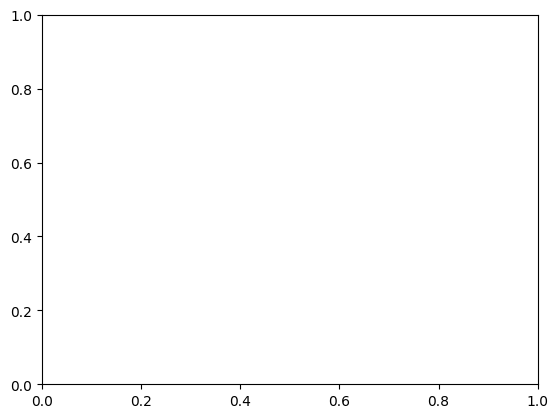

In [9]:
import matplotlib.pyplot as plt
plt.scatter(X,y, color = 'Blue', Label = "Features")
plt.plot(X,y_pred, color='red',label='Regression line')
plt.xlabel('Features')
plt.ylabel("Sales")
plt.legend()
plt.show()

In [10]:
X.shape

(20640, 8)

In [11]:
y.shape

(20640,)